## Desarrollo tarea HW Sesión 4

Felipe López Vergara

## 1. Simulación

Suponga un proceso $\epsilon_t$ con media cero y varianza igual a 3. Se sabe que, $\mathbb{E}(y_t) = 10$ y condición inicial es $y_1 = 9$ y $y_2 = 10.3$. Simule, recursivamente, 100 periodos para la variable $y_t$ para los siguientes modelos.

In [2]:
from matplotlib import pyplot as plt 
from scipy.stats import lognorm
import statsmodels.api as sm
import pandas as pd 
import seaborn as sns
import yfinance as yf
import numpy as np

sns.set_style("dark")

*AR(1) con $\phi_1 = 0,4$, $\phi_1 = 0,8$ y $\phi_1 = 0,99$

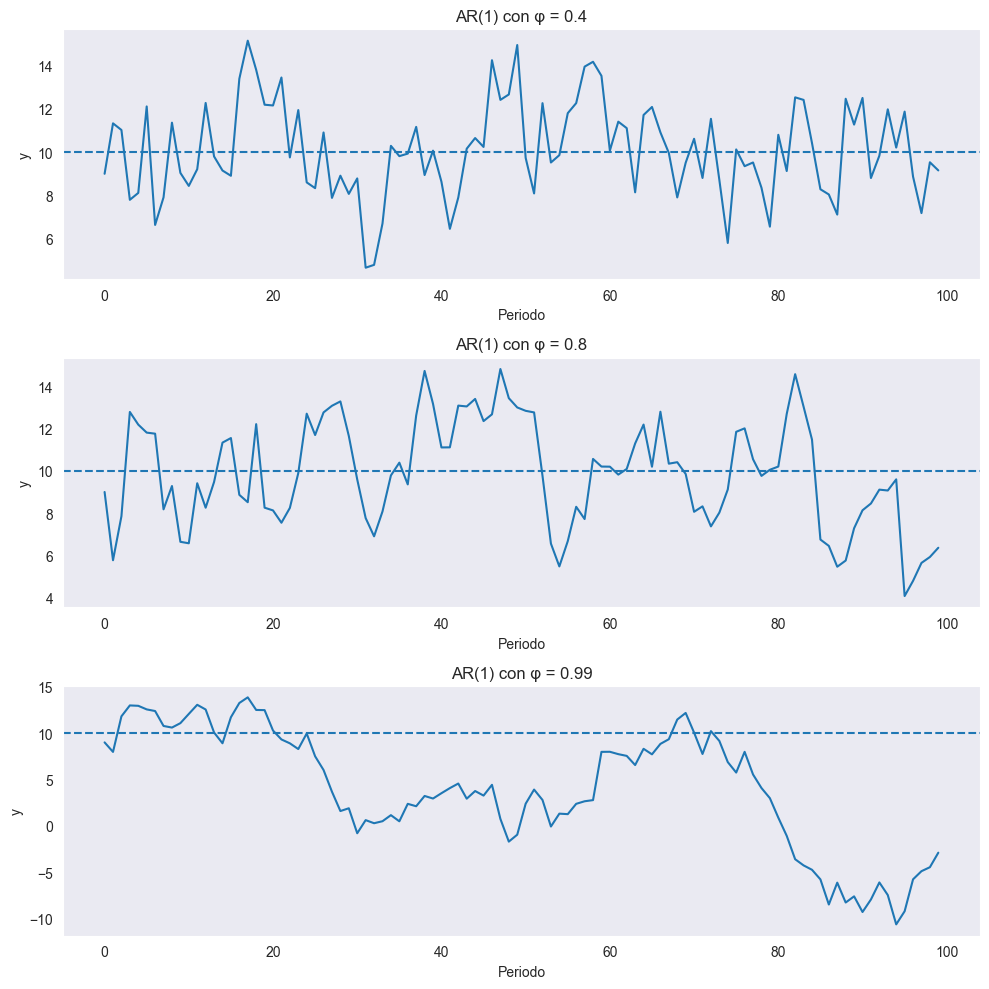

In [ ]:
from statsmodels.tsa.arima_process import ArmaProcess

# Fijar semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
sigma = np.sqrt(3)

# Valores de phi
phis = [0.4, 0.8, 0.99]

# Crear una figura
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

for i, phi in enumerate(phis):

    # Generar errores
    e = np.random.normal(0, sigma, T)

    # Inicializar la serie
    y = np.zeros(T)
    y[0] = 9

    # Simulación recursiva
    for t in range(1, T):
        y[t] = mu + phi*(y[t-1] - mu) + e[t]

    # Graficar
    ax[i].plot(y)
    ax[i].axhline(mu, linestyle='--')
    ax[i].set_title(f'AR(1) con φ = {phi}')
    ax[i].set_xlabel('Periodo')
    ax[i].set_ylabel('y')

plt.tight_layout()
plt.show()

*AR(2) con $\phi_1 = 0,2$, $\phi_1 = 0,4$ y $\phi_1 = 0,8$ y $\phi_2 = -0,05$

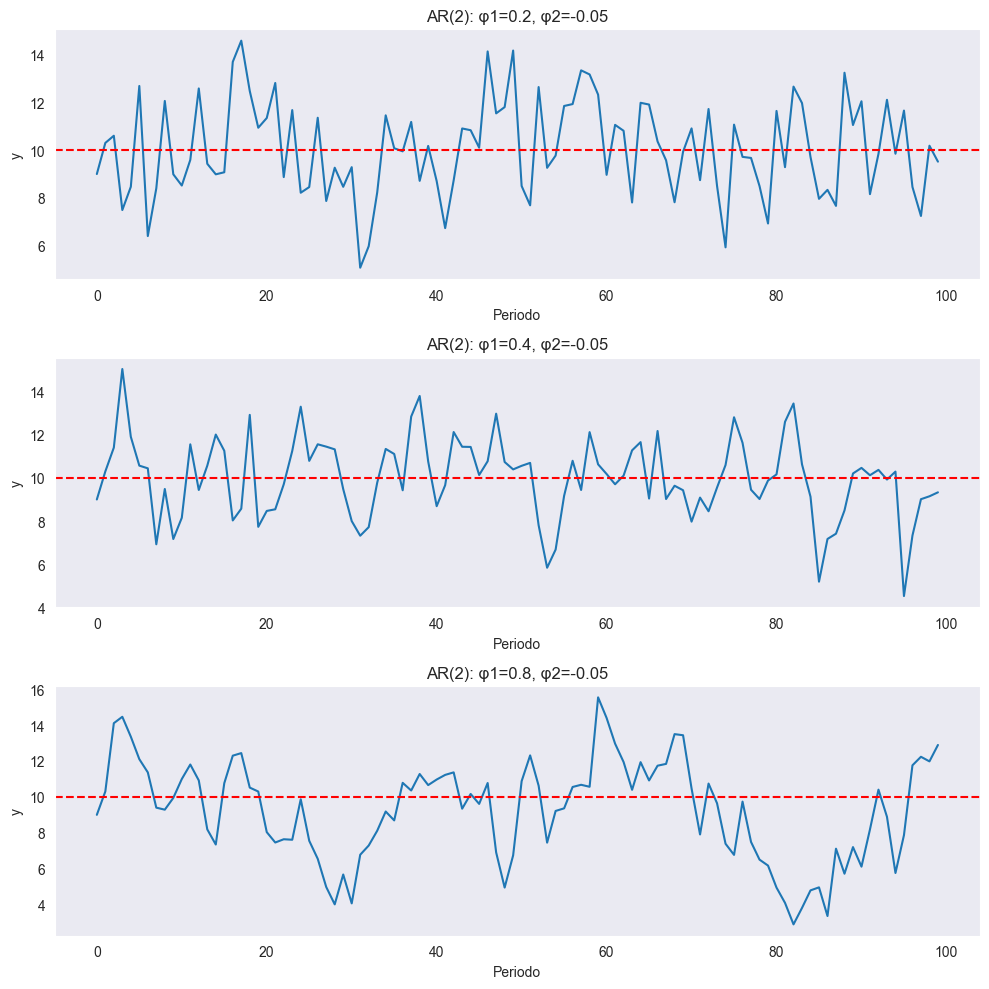

In [7]:
# Semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
sigma = np.sqrt(3)

# Valores de phi1
phi1_vals = [0.2, 0.4, 0.8]
phi2 = -0.05

# DataFrame para guardar las simulaciones
simulaciones = pd.DataFrame(index=range(1, T+1))

# Crear gráficos
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

for i, phi1 in enumerate(phi1_vals):

    # Generar errores
    e = np.random.normal(0, sigma, T)

    # Inicializar la serie
    y = np.zeros(T)
    y[0] = 9
    y[1] = 10.3

    # Simulación recursiva
    for t in range(2, T):
        y[t] = (mu
                + phi1*(y[t-1] - mu)
                + phi2*(y[t-2] - mu)
                + e[t])

    # Guardar resultados
    simulaciones[f'AR2_phi1_{phi1}'] = y

    # Graficar
    ax[i].plot(y)
    ax[i].axhline(mu, color='red', linestyle='--')
    ax[i].set_title(f'AR(2): φ1={phi1}, φ2={phi2}')
    ax[i].set_xlabel('Periodo')
    ax[i].set_ylabel('y')

plt.tight_layout()
plt.show()

*MA(1) con $\theta_1 = 0.5$ y $\theta_1 = 2$

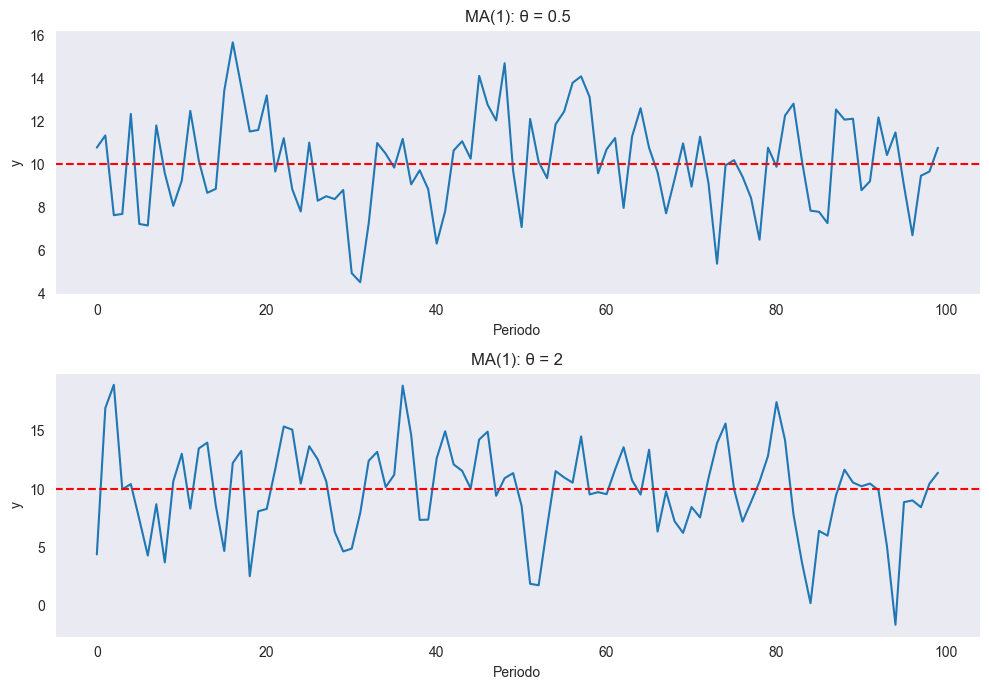

In [8]:
# Semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
sigma = np.sqrt(3)

# Valores de theta
thetas = [0.5, 2]

# DataFrame para guardar simulaciones
simulaciones = pd.DataFrame(index=range(1, T+1))

# Generar gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

for i, theta in enumerate(thetas):

    # Generar errores
    e = np.random.normal(0, sigma, T + 1)

    # Inicializar serie
    y = np.zeros(T)

    # Simulación recursiva
    for t in range(T):
        y[t] = mu + e[t+1] + theta * e[t]

    # Guardar resultados
    simulaciones[f'MA1_theta_{theta}'] = y

    # Graficar
    ax[i].plot(y)
    ax[i].axhline(mu, color='red', linestyle='--')
    ax[i].set_title(f'MA(1): θ = {theta}')
    ax[i].set_xlabel('Periodo')
    ax[i].set_ylabel('y')

plt.tight_layout()
plt.show()

*ARMA(1,1) con $\phi_1 = 0,4$ y $\theta_1 = 0,5$

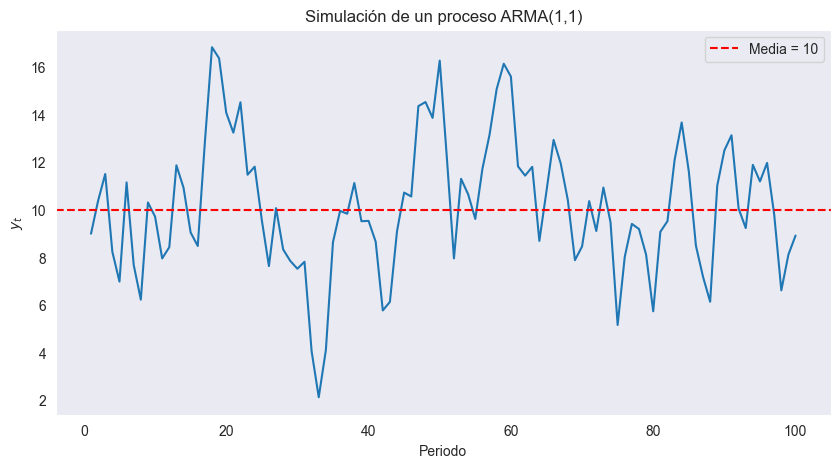

In [10]:
# Semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
phi = 0.4
theta = 0.5
sigma = np.sqrt(3)

# Generar errores
e = np.random.normal(0, sigma, T + 1)

# Inicializar la serie
y = np.zeros(T)
y[0] = 9

# Simulación recursiva
for t in range(1, T):
    y[t] = (mu
            + phi*(y[t-1] - mu)
            + e[t]
            + theta*e[t-1])

# Guardar en DataFrame
df = pd.DataFrame({
    'Periodo': np.arange(1, T+1),
    'ARMA(1,1)': y
})

# Graficar
plt.figure(figsize=(10,5))
plt.plot(df['Periodo'], df['ARMA(1,1)'])
plt.axhline(mu, color='red', linestyle='--', label='Media = 10')
plt.xlabel('Periodo')
plt.ylabel('$y_t$')
plt.title('Simulación de un proceso ARMA(1,1)')
plt.legend()
plt.show()